# AIoT Project — Feature-Engineering solution

Human Activity Recognition on **PAMAP2**, ML solution **#2**: instead of the
raw windowed signal, we extract a set of **time- and frequency-domain
features** per window, **select** the most discriminative ones, and feed those
to the classifiers. We then **compare the full feature set against the selected
subset**, and compare sensor placements.

All inputs are fetched from **MongoDB** (`Protocol` split, 12 activities,
9 subjects); the raw `.dat` files are never read here.

In [1]:
import os
import pandas as pd
import numpy as np
import scipy
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import pymongo
import yaml
from time import time

from utils import sliding_window_pd
from utils import apply_filter
from utils import load_segments
from utils import window_segments
from utils import filter_windows
from utils import axis_features
from utils import extract_features
from utils import features_matrix
from utils import train_and_score
from utils import evaluate
from utils import load_combo
from utils import run_combo_fe

from utils_visual import plot_heatmap

%load_ext autoreload
%autoreload 2

IMG_DIR = "img"
os.makedirs(IMG_DIR, exist_ok=True)
time_start = time()

## Load configuration

In [2]:
config_path = os.path.join(os.getcwd(), "config.yml")
with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

SW = config["sliding_window"]
FILT = config["filter"]
SPLIT = config["split"]
print("window:", SW["ws"], "overlap:", SW["overlap"], "| filter:", FILT)

window: 256 overlap: 128 | filter: {'order': 4, 'wn': 0.2, 'type': 'lowpass'}


In [3]:
client = pymongo.MongoClient(config["client"])
db = client[config["db"]]
coll = db[config["col"]]
coll.count_documents({})

324

In [4]:
found_labels = coll.distinct("activity_label")
print("Activities in DB:", found_labels)

Activities in DB: ['ascending_stairs', 'cycling', 'descending_stairs', 'ironing', 'lying', 'nordic_walking', 'rope_jumping', 'running', 'sitting', 'standing', 'vacuum_cleaning', 'walking']


## Load data

Hand/wrist IMU, AccGyr configuration. Each document becomes a 6-channel
DataFrame carrying its `activity_label` and `subject`.

In [5]:
segments = load_segments(coll, "hand")
print("hand segments:", len(segments))

hand segments: 108


## Data Processing — windowing & filtering

Same segmentation and low-pass filtering as the time-series notebook (the two
solutions share their front-end so the comparison is fair); the difference is
what we compute from each window.

In [6]:
windows, y, subjects = window_segments(segments, SW["ws"], SW["overlap"], SW["w_type"])
windows = filter_windows(windows, FILT["order"], FILT["wn"], FILT["type"])
print("windows:", len(windows), "| shape:", windows[0].shape)

windows: 15023 | shape: (256, 6)


## Feature engineering

For every window and every channel we compute **time-domain** features (mean,
std, min, max, median, IQR, RMS, MAD, energy, skewness, kurtosis,
zero-crossing rate) and **frequency-domain** features (dominant frequency,
spectral energy, spectral entropy via the real FFT). We also add the pairwise
**channel correlations**, a cheap coordination/orientation cue that separates,
e.g., walking from cycling.

In [7]:
t = time()
Xfe = features_matrix(windows)
print(f"feature matrix {Xfe.shape} built in {time() - t:.1f}s")
Xfe.head()

feature matrix (15023, 105) built in 99.3s


,acc_x__mean,acc_x__std,acc_x__min,acc_x__max,acc_x__median,acc_x__iqr,acc_x__rms,acc_x__mad,acc_x__energy,acc_x__skew,...,corr__acc_y__acc_z,corr__acc_y__gyr_x,corr__acc_y__gyr_y,corr__acc_y__gyr_z,corr__acc_z__gyr_x,corr__acc_z__gyr_y,corr__acc_z__gyr_z,corr__gyr_x__gyr_y,corr__gyr_x__gyr_z,corr__gyr_y__gyr_z
0,0.234083,1.909975,-2.725163,2.917144,-0.554278,3.761935,1.924266,1.800046,3.702800,0.112459,...,-0.756265,0.312086,-0.137562,0.246595,-0.156508,0.145520,-0.315601,0.149639,-0.107514,0.540582
1,-1.603190,0.738222,-3.040593,0.163104,-1.515045,1.098427,1.764990,0.608060,3.115188,-0.082679,...,-0.771333,0.016048,-0.219458,-0.151738,0.076326,0.489208,0.281234,-0.302481,-0.638924,0.773867
2,-1.321980,0.791040,-3.040593,-0.083465,-1.111393,1.152979,1.540576,0.653713,2.373375,-0.554874,...,-0.852192,0.063014,0.056791,-0.074882,-0.118192,0.002932,0.152067,-0.808948,-0.801963,0.878019
3,-1.500302,1.090896,-3.948485,0.648952,-1.090597,2.020793,1.854983,0.957951,3.440961,-0.468023,...,-0.683890,-0.006013,0.215844,0.235341,0.205918,-0.280813,-0.291590,-0.358293,-0.633967,0.142082
4,-2.368530,1.137838,-4.418013,0.714083,-2.707684,0.424122,2.627662,0.860450,6.904609,0.992822,...,-0.565877,0.505065,-0.443982,0.384987,-0.445938,0.292592,-0.691568,-0.421588,0.184598,-0.347239


Input vector after feature engineering — number of features per window:

In [8]:
print("features per window:", Xfe.shape[1])
print(list(Xfe.columns)[:12], "...")

features per window: 105
['acc_x__mean', 'acc_x__std', 'acc_x__min', 'acc_x__max', 'acc_x__median', 'acc_x__iqr', 'acc_x__rms', 'acc_x__mad', 'acc_x__energy', 'acc_x__skew', 'acc_x__kurtosis', 'acc_x__zcr'] ...


## Train/Test split (subject-disjoint)

6 subjects train / 3 test, no overlap — identical scheme to the time-series
notebook.

In [9]:
TRAIN_SUBJECTS = SPLIT["train_subjects"]
TEST_SUBJECTS = SPLIT["test_subjects"]
assert set(TRAIN_SUBJECTS).isdisjoint(TEST_SUBJECTS)

train_mask = np.isin(subjects, TRAIN_SUBJECTS)
test_mask = np.isin(subjects, TEST_SUBJECTS)
Xtr_df, Xte_df = Xfe[train_mask].reset_index(drop=True), Xfe[test_mask].reset_index(drop=True)
y_train, y_test = y[train_mask], y[test_mask]
print("train:", Xtr_df.shape, "| test:", Xte_df.shape)

train: (11014, 105) | test: (4009, 105)


## Scaling

Standardize the features, fitting the scaler **only on the training
subjects**.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(Xtr_df.values)
X_train = scaler.transform(Xtr_df.values)
X_test = scaler.transform(Xte_df.values)

## Dimensionality reduction — PCA

We fit PCA on the (scaled) training features to retain 95% of the variance and
visualize the class structure on the first two principal components. (We keep
the original features for classification; PCA here is exploratory.)

components for 95% variance: 45


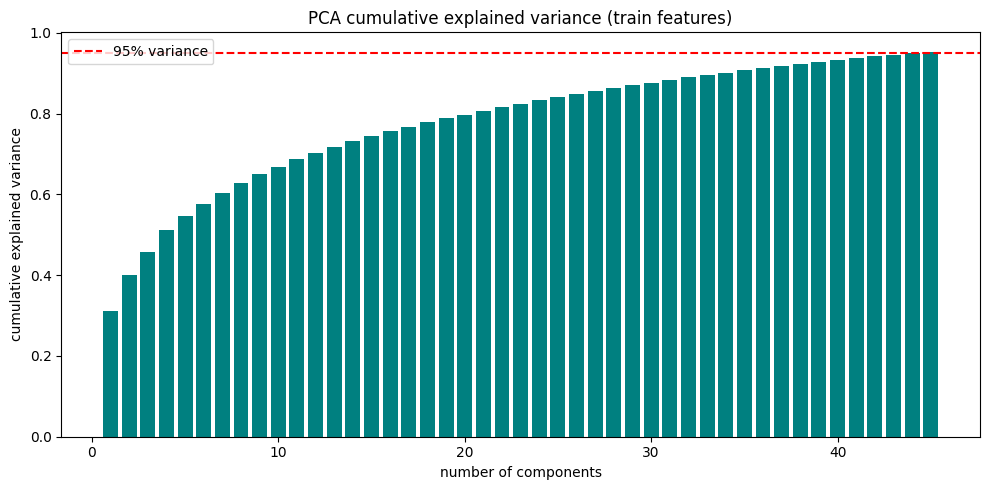

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=config["PCA"]["n_comp"]).fit(X_train)
print("components for 95% variance:", pca.n_components_)

# explained variance bar (replaces psynlig.pca_explained_variance_bar)
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        np.cumsum(pca.explained_variance_ratio_), color="teal")
plt.axhline(0.95, color="red", ls="--", label="95% variance")
plt.xlabel("number of components"); plt.ylabel("cumulative explained variance")
plt.title("PCA cumulative explained variance (train features)"); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "fe_pca_variance.png"), dpi=120)
plt.show()

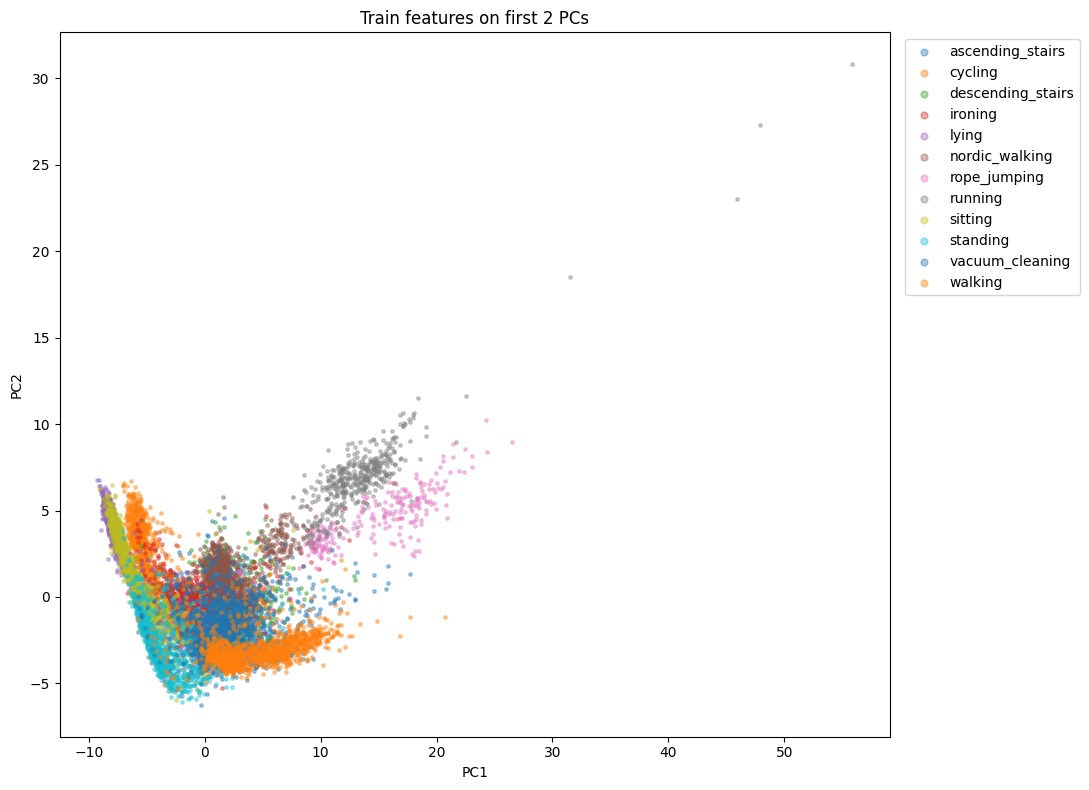

In [12]:
# Scatter of the first two principal components, colored by activity
pcs = pca.transform(X_train)[:, :2]
plt.figure(figsize=(11, 8))
for lab in sorted(np.unique(y_train)):
    m = y_train == lab
    plt.scatter(pcs[m, 0], pcs[m, 1], s=6, alpha=0.4, label=lab)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Train features on first 2 PCs")
plt.legend(markerscale=2, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "fe_pca_scatter.png"), dpi=120)
plt.show()

## Classifier — Statistical Learning

### Apply & evaluate simple classifiers (full feature set)

=== Features — Random Forest (hand, full set) ===
accuracy: 0.767 | macro-F1: 0.760

                   precision    recall  f1-score   support

 ascending_stairs       0.66      0.69      0.67       190
          cycling       0.81      0.92      0.86       357
descending_stairs       0.74      0.78      0.76       157
          ironing       0.60      0.70      0.65       549
            lying       0.86      0.91      0.88       368
   nordic_walking       0.98      0.49      0.65       431
     rope_jumping       1.00      0.49      0.66       116
          running       0.89      0.92      0.90       305
          sitting       0.77      0.85      0.81       357
         standing       0.83      0.59      0.69       384
  vacuum_cleaning       0.58      0.87      0.69       351
          walking       0.93      0.87      0.90       444

         accuracy                           0.77      4009
        macro avg       0.80      0.76      0.76      4009
     weighted avg       0.80

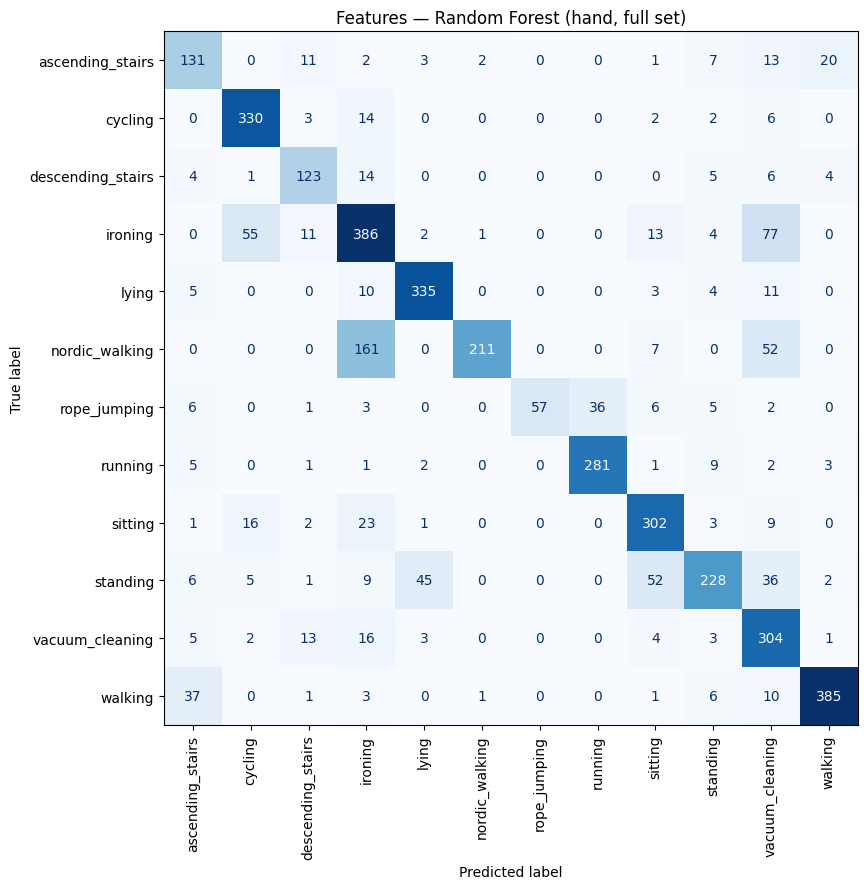

=== Features — SVM RBF (hand, full set) ===
accuracy: 0.634 | macro-F1: 0.605

                   precision    recall  f1-score   support

 ascending_stairs       0.59      0.73      0.65       190
          cycling       0.89      0.95      0.92       357
descending_stairs       0.77      0.75      0.76       157
          ironing       0.82      0.43      0.56       549
            lying       0.74      0.93      0.83       368
   nordic_walking       1.00      0.47      0.64       431
     rope_jumping       0.96      0.20      0.33       116
          running       0.34      0.03      0.06       305
          sitting       0.30      0.73      0.42       357
         standing       0.76      0.63      0.69       384
  vacuum_cleaning       0.44      0.89      0.59       351
          walking       0.98      0.72      0.83       444

         accuracy                           0.63      4009
        macro avg       0.71      0.62      0.61      4009
     weighted avg       0.72      

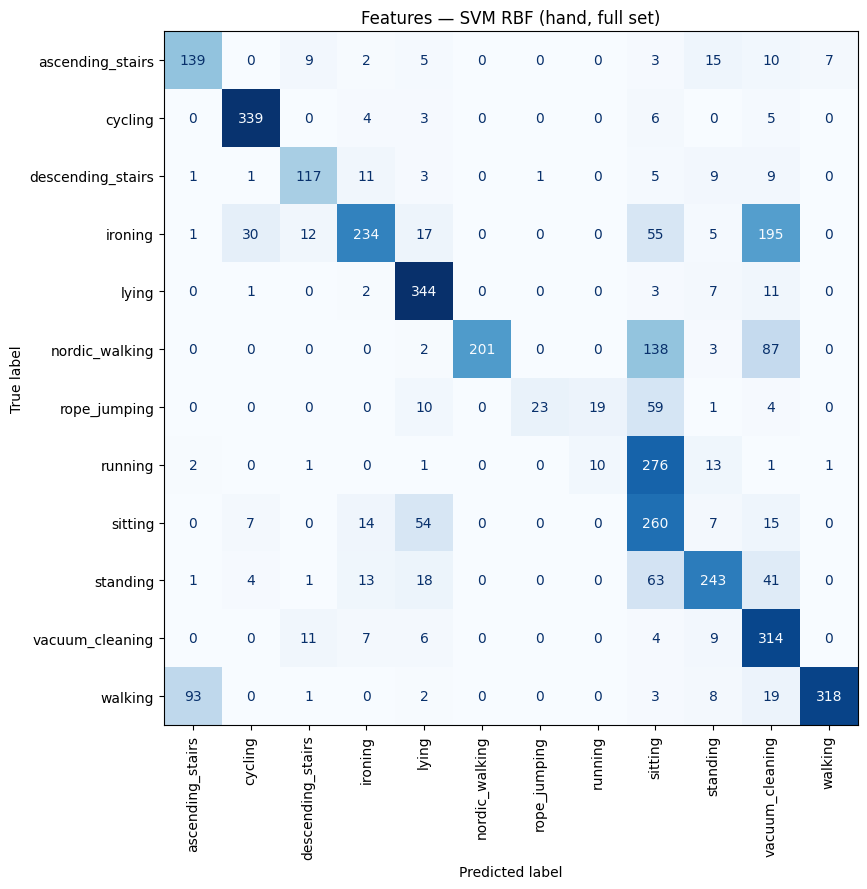

In [13]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score, f1_score)

rf_cfg = config["classifier"]["RandomForest"]
svc_cfg = config["classifier"]["SVC"]


rf = RandomForestClassifier(n_estimators=rf_cfg["n_estimators"],
                            max_depth=rf_cfg["max_depth"],
                            random_state=42, n_jobs=-1).fit(X_train, y_train)
svm = SVC(C=svc_cfg["C"], kernel=svc_cfg["kernel"], gamma=svc_cfg["gamma"]).fit(X_train, y_train)

evaluate(rf, X_test, y_test, "Features — Random Forest (hand, full set)", "fe_cm_rf.png")
evaluate(svm, X_test, y_test, "Features — SVM RBF (hand, full set)", "fe_cm_svm.png");

## Feature selection

Which features are discriminative? We rank them by **Random Forest impurity
importance** (fit on the training set) and keep the top-K. We then retrain on
this subset and compare against the full set — fewer features that retain (or
improve) performance mean a cheaper, more interpretable model.

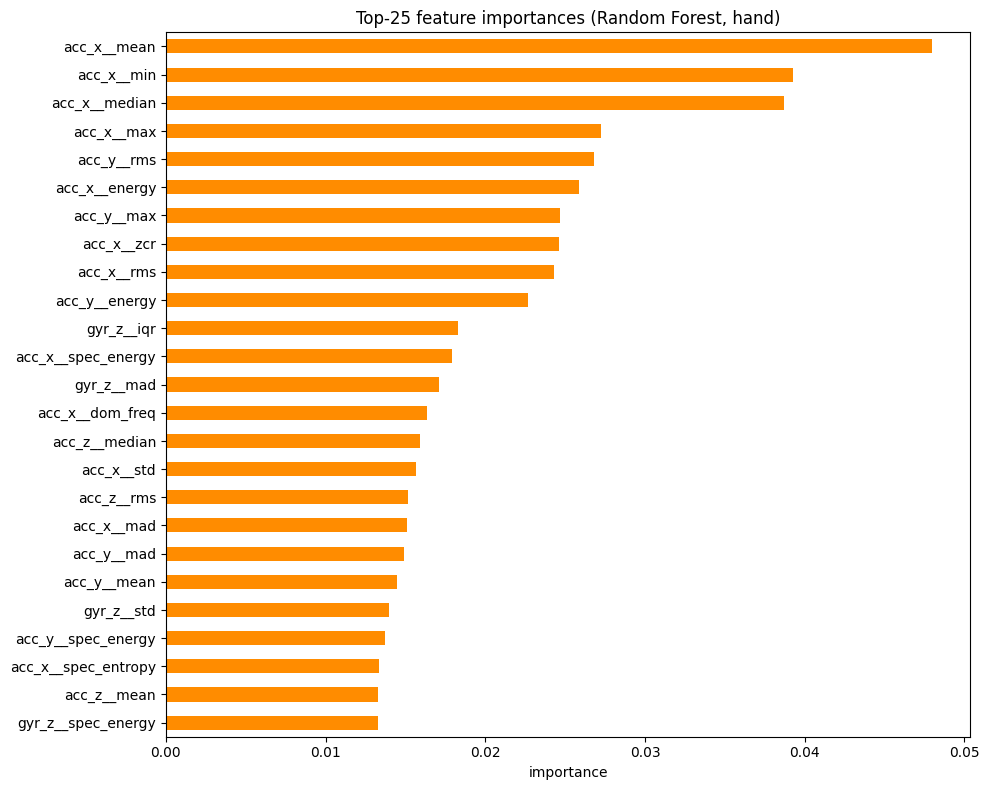

selected top-30 features
['acc_x__mean', 'acc_x__min', 'acc_x__median', 'acc_x__max', 'acc_y__rms', 'acc_x__energy', 'acc_y__max', 'acc_x__zcr', 'acc_x__rms', 'acc_y__energy'] ...


In [14]:
importances = pd.Series(rf.feature_importances_, index=Xfe.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(25).iloc[::-1].plot(kind="barh", color="darkorange")
plt.title("Top-25 feature importances (Random Forest, hand)")
plt.xlabel("importance"); plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "fe_feature_importances.png"), dpi=120)
plt.show()

K = 30
selected = list(importances.head(K).index)
print(f"selected top-{K} features")
print(selected[:10], "...")

### Full feature set vs selected subset

In [15]:
# Column positions of the selected features inside the scaled matrices
selected_positions = [Xfe.columns.get_loc(name) for name in selected]
X_train_selected = X_train[:, selected_positions]
X_test_selected = X_test[:, selected_positions]


# The two feature sets we want to compare
feature_sets = [
    (f"full ({Xfe.shape[1]} feat)", X_train, X_test),
    (f"selected ({K} feat)", X_train_selected, X_test_selected),
]

rows = []
for set_name, X_tr, X_te in feature_sets:
    rf_model = RandomForestClassifier(n_estimators=rf_cfg["n_estimators"],
                                      max_depth=rf_cfg["max_depth"],
                                      random_state=42, n_jobs=-1)
    acc, f1m = train_and_score(rf_model, X_tr, y_train, X_te, y_test)
    rows.append({"feature_set": set_name, "model": "RF",
                 "accuracy": acc, "macro_f1": f1m})

    svm_model = SVC(C=svc_cfg["C"], kernel=svc_cfg["kernel"], gamma=svc_cfg["gamma"])
    acc, f1m = train_and_score(svm_model, X_tr, y_train, X_te, y_test)
    rows.append({"feature_set": set_name, "model": "SVM",
                 "accuracy": acc, "macro_f1": f1m})

cmp_df = pd.DataFrame(rows)
print(cmp_df.round(3).to_string(index=False))

       feature_set model  accuracy  macro_f1
   full (105 feat)    RF     0.767     0.760
   full (105 feat)   SVM     0.634     0.605
selected (30 feat)    RF     0.722     0.711
selected (30 feat)   SVM     0.690     0.644


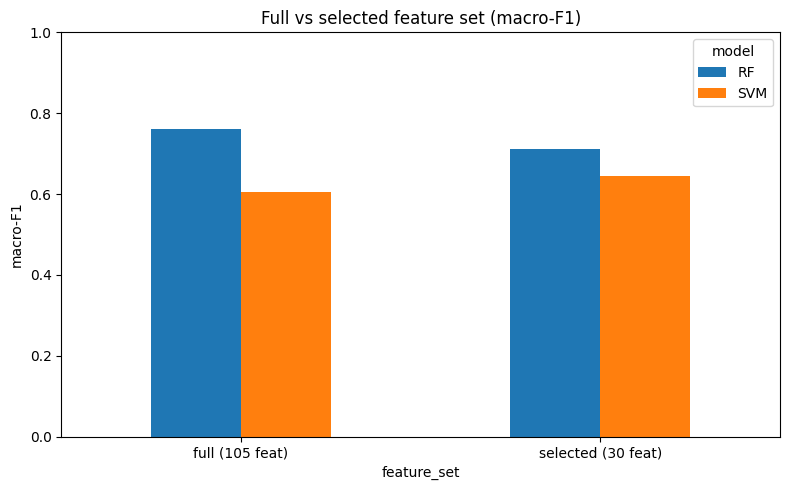

In [16]:
pivot = cmp_df.pivot(index="feature_set", columns="model", values="macro_f1")
ax = pivot.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1)
ax.set_title("Full vs selected feature set (macro-F1)")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "fe_full_vs_selected.png"), dpi=120)
plt.show()

## Apply optimization with Grid Search and/or Cross-validation

We run the exhaustive **SVM** `GridSearchCV` from `config.yml`. A libsvm SVC
with a linear kernel and a large `C` scales poorly (O(n^2)) with the ~11k
training windows, so we run the search on a **stratified sub-sample** of the
training set (fast), then **refit** the winning hyper-parameters on the *full*
training set. The sub-sample only steers hyper-parameter selection; the final
model still sees all training data.

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

# Stratified sub-sample of the training windows for the hyper-parameter search.
n_sub = min(4000, len(y_train))
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=n_sub,
                                      stratify=y_train, random_state=42)
print("grid-search sub-sample:", X_sub.shape)

param_grid = config["fine_tune"]["param_grid"]
gs = GridSearchCV(SVC(), param_grid, cv=3,
                  verbose=config["fine_tune"]["verbose"], n_jobs=-1)
t = time()
gs.fit(X_sub, y_sub)
print(f"\ngrid search done in {time() - t:.1f}s")
print("best params:", gs.best_params_)
print("best CV score (sub-sample):", round(gs.best_score_, 3))

# Refit the winning configuration on the FULL training set.
best_svm = SVC(**gs.best_params_).fit(X_train, y_train)

grid-search sub-sample: (4000, 105)
Fitting 3 folds for each of 12 candidates, totalling 36 fits



grid search done in 45.3s
best params: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
best CV score (sub-sample): 0.857


### Evaluate optimized classifier

=== Features — tuned SVM (hand, full set) ===
accuracy: 0.711 | macro-F1: 0.706

                   precision    recall  f1-score   support

 ascending_stairs       0.65      0.74      0.69       190
          cycling       0.90      0.96      0.93       357
descending_stairs       0.64      0.82      0.72       157
          ironing       0.80      0.40      0.53       549
            lying       0.70      0.94      0.80       368
   nordic_walking       1.00      0.47      0.64       431
     rope_jumping       0.97      0.30      0.46       116
          running       0.96      0.92      0.94       305
          sitting       0.63      0.76      0.69       357
         standing       0.75      0.65      0.70       384
  vacuum_cleaning       0.37      0.86      0.52       351
          walking       0.97      0.76      0.85       444

         accuracy                           0.71      4009
        macro avg       0.78      0.71      0.71      4009
     weighted avg       0.79    

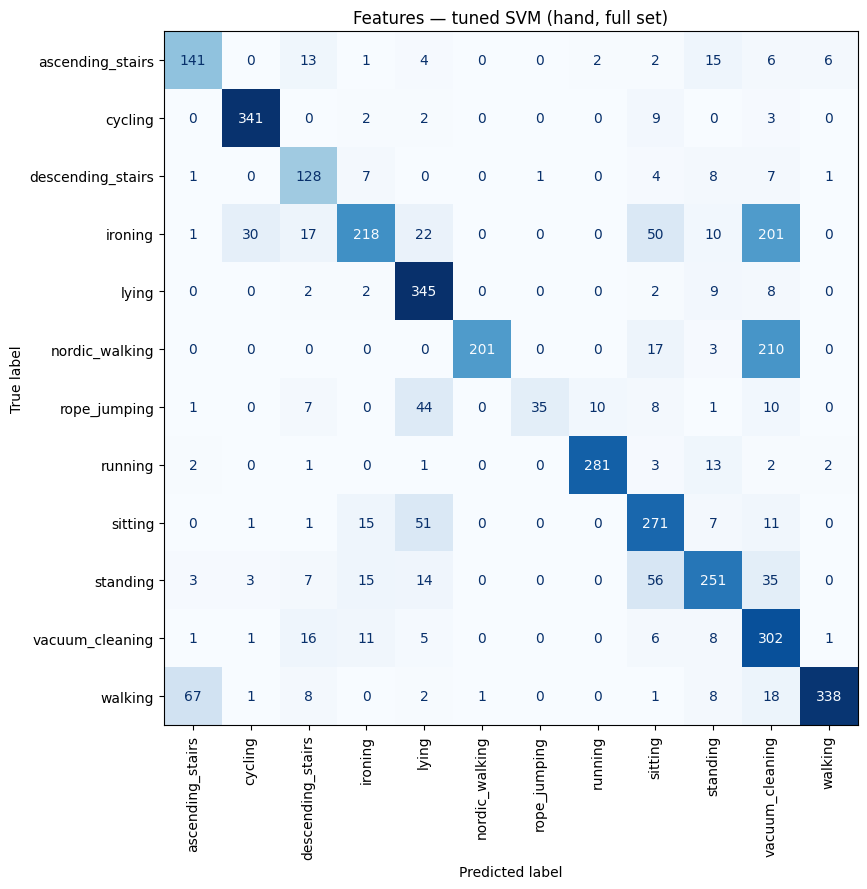

In [18]:
evaluate(best_svm, X_test, y_test,
         "Features — tuned SVM (hand, full set)", "fe_cm_tuned.png");

## Sensor configuration comparison

We run the full feature pipeline (window → filter → features → subject-disjoint
split → scale → tuned-SVM) for the **incremental** sensor configurations the
assignment asks for:

- `hand` (baseline),
- `hand + chest`,
- `hand + ankle`,
- `hand + chest + ankle`.

The channels of the additional IMUs are concatenated to the wrist channels per
segment before feature extraction, so the feature vector grows accordingly
(105 features for one IMU, 210 for two, 315 for three).

In [19]:
best_svc = gs.best_params_

combos = [["hand"], ["hand", "chest"], ["hand", "ankle"], ["hand", "chest", "ankle"]]
results = [run_combo_fe(coll, c, SW, FILT, TRAIN_SUBJECTS, TEST_SUBJECTS, best_svc) for c in combos]
res_df = pd.DataFrame(results).set_index("combo")
print(res_df.round(3))

                  n_features  accuracy  macro_f1
combo                                           
hand                     105     0.711     0.706
hand+chest               246     0.794     0.793
hand+ankle               246     0.708     0.708
hand+chest+ankle         423     0.775     0.764


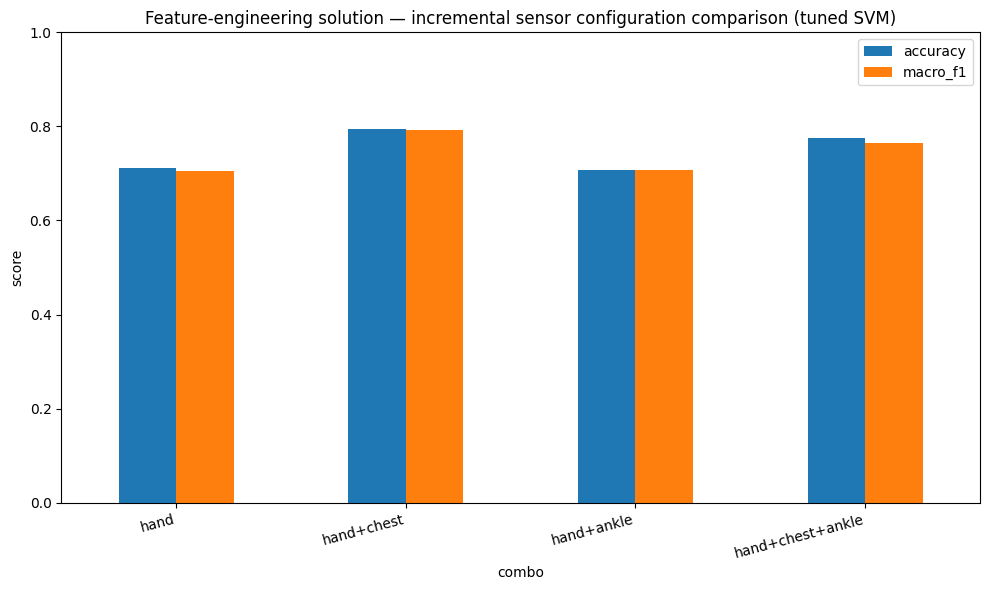

In [20]:
ax = res_df[["accuracy", "macro_f1"]].plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("score"); ax.set_ylim(0, 1)
ax.set_title("Feature-engineering solution — incremental sensor configuration comparison (tuned SVM)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "fe_sensor_comparison.png"), dpi=120)
plt.show()

In [21]:
print(f"Notebook total runtime: {time() - time_start:.1f}s")

Notebook total runtime: 1560.6s
